# Assignment-4

This notebook contains the coding questions to test the proficiency in `Object Oriented Programming` in python.

### Date: 13th September, 2026

### Steps to solve and upload the assignment 

- Download the notebook in your local machine.
- Solve the questions in the notebook and save it.
- Rename the file as `Assignment-04-<your_name>_<your_surname>.ipynb`. For example if your name is Dipika Chopra then name the file as `Assignment-04-Dipika_Chopra.ipynb`.
- Upload the solved notebook in your github repo under the folder **Assignment-4**.
- Upload the solved notebook in the google drive location: https://drive.google.com/drive/folders/1orNSmlOr2wMcrnu6zYeLwsY_JeUodCUq?usp=drive_link 
<h3><span style="color:red"> Deadline: 30th Sep, 2026 </span></h3>

## Problem-1

Design a system for a library. Include classes for `Book`, `Patron`, and `Library`.

- The `Book` class should have attributes for title, author, ISBN, and a method `is_available()` that returns `True` if the book is not currently checked out and `False` otherwise. It should also have a method `check_out()` that marks the book as checked out and a method `check_in()` that marks it as available.
- The `Patron` class should have attributes for name and patron ID and a method `borrow_book(book)` that associates a book with the patron.
- The `Library` class should have a collection of `Book` objects and `Patron` objects. It should have methods to `add_book(book)`, `add_patron(patron)`, `lend_book(book, patron)`, and `return_book(book)`. The `lend_book` method should only allow a book to be lent if it's available and the patron exists in the library.


Test your implementation.

In [1]:
class Book:
    def __init__(self, title, author, isbn):
        """Initialise a Book object with title, author, isbn, and tracking status."""
        self.title = title
        self.author = author
        self.isbn = isbn
        self._is_checked_out = False  # Internal tracking variable

    def is_available(self):
        """Returns True if the book is not currently checked out, False otherwise."""
        return not self._is_checked_out

    def check_out(self):
        """Marks the book as checked out. Returns True if successful, False if already out."""
        if self._is_checked_out:
            return False
        self._is_checked_out = True
        return True

    def check_in(self):
        """Marks the book as available again."""
        self._is_checked_out = False

    def __str__(self):
        return f"'{self.title}' by {self.author} (ISBN: {self.isbn})"


class Patron:
    def __init__(self, name, patron_id):
        """Initialise a Patron object with a name, unique ID, and a list of borrowed books."""
        self.name = name
        self.patron_id = patron_id
        self.borrowed_books = []  # Stores associated Book objects

    def borrow_book(self, book):
        """Associates a book with the patron."""
        if book not in self.borrowed_books:
            self.borrowed_books.append(book)

    def return_book(self, book):
        """Removes the book association when returned."""
        if book in self.borrowed_books:
            self.borrowed_books.remove(book)

    def __str__(self):
        return f"Patron: {self.name} (ID: {self.patron_id})"


class Library:
    def __init__(self):
        """Initialise the Library with internal dictionary collections for rapid lookup."""
        self.books = {}    # Key: ISBN (string) -> Value: Book object
        self.patrons = {}  # Key: Patron ID (string) -> Value: Patron object

    def add_book(self, book):
        """Adds a Book object to the library collection."""
        self.books[book.isbn] = book
        print(f"Library: Added book {book}")

    def add_patron(self, patron):
        """Adds a Patron object to the library registry."""
        self.patrons[patron.patron_id] = patron
        print(f"Library: Registered patron {patron}")

    def lend_book(self, book, patron):
        """Lends a book if it's available and the patron exists in the library."""
        # Condition Check: Verify patron exists in the system
        if patron.patron_id not in self.patrons:
            print(f"Transaction Failed: Patron '{patron.name}' is not registered in this library.")
            return False
        
        # Condition Check: Verify the book belongs to this library catalog
        if book.isbn not in self.books:
            print(f"Transaction Failed: Book '{book.title}' does not belong to this library system.")
            return False

        # Condition Check: Check if book is available
        if not book.is_available():
            print(f"Transaction Failed: '{book.title}' is already checked out.")
            return False

        # Execution Phase
        book.check_out()
        patron.borrow_book(book)
        print(f"Transaction Success: '{book.title}' has been successfully lent to {patron.name}.")
        return True

    def return_book(self, book):
        """Processes the return of a book."""
        if book.isbn not in self.books:
            print(f"Transaction Failed: Book '{book.title}' does not belong to this library.")
            return False

        # Find which patron currently has this book to clean up their list
        for patron in self.patrons.values():
            if book in patron.borrowed_books:
                patron.return_book(book)
                break
        
        book.check_in()
        print(f"Transaction Success: '{book.title}' has been safely checked back in.")
        return True


# ==========================================
# SYSTEM TEST LOGIC
# ==========================================
if __name__ == "__main__":
    print("--- 1. Setting up Library Architecture ---")
    my_library = Library()

    # Create Instances
    book1 = Book("1984", "George Orwell", "9780451524935")
    book2 = Book("To Kill a Mockingbird", "Harper Lee", "9780446310789")
    patron1 = Patron("Alice Smith", "P001")
    patron2 = Patron("Bob Jones", "P002")
    unregistered_patron = Patron("Charlie Brown", "P999")

    # Add items to the system
    my_library.add_book(book1)
    my_library.add_book(book2)
    my_library.add_patron(patron1)
    my_library.add_patron(patron2)
    print("\n--- 2. Executing Operational Scenarios ---")

    # Scenario A: Successful lending
    print("Test A (Valid Lend):")
    my_library.lend_book(book1, patron1)
    print(f"Is '1984' available now? {book1.is_available()}")
    print(f"Alice's current inventory count: {len(patron1.borrowed_books)}")
    print("-" * 40)

    # Scenario B: Unsuccessful lending (Book already out)
    print("Test B (Double Checkout Failure):")
    my_library.lend_book(book1, patron2)
    print("-" * 40)

    # Scenario C: Unsuccessful lending (Unregistered User)
    print("Test C (Security/Registry Check Failure):")
    my_library.lend_book(book2, unregistered_patron)
    print("-" * 40)

    # Scenario D: Return handling verification
    print("Test D (Valid Return processing):")
    my_library.return_book(book1)
    print(f"Is '1984' available again? {book1.is_available()}")
    print(f"Alice's inventory count post-return: {len(patron1.borrowed_books)}")

--- 1. Setting up Library Architecture ---
Library: Added book '1984' by George Orwell (ISBN: 9780451524935)
Library: Added book 'To Kill a Mockingbird' by Harper Lee (ISBN: 9780446310789)
Library: Registered patron Patron: Alice Smith (ID: P001)
Library: Registered patron Patron: Bob Jones (ID: P002)

--- 2. Executing Operational Scenarios ---
Test A (Valid Lend):
Transaction Success: '1984' has been successfully lent to Alice Smith.
Is '1984' available now? False
Alice's current inventory count: 1
----------------------------------------
Test B (Double Checkout Failure):
Transaction Failed: '1984' is already checked out.
----------------------------------------
Test C (Security/Registry Check Failure):
Transaction Failed: Patron 'Charlie Brown' is not registered in this library.
----------------------------------------
Test D (Valid Return processing):
Transaction Success: '1984' has been safely checked back in.
Is '1984' available again? True
Alice's inventory count post-return: 0


## Problem-2

Create an base class `Shape` with an method `area()` and another method `perimeter()`. Then, create classes `Rectangle` and `Circle` that inherit from `Shape` and implement the `area()` method. The `perimeter()` method in `Shape` should raise a `NotImplementedError`. Implement the `perimeter()` method in `Rectangle` and `Circle`.

Test your implementation.

In [2]:
import math

class Shape:
    def area(self):
        """Calculates the area of the shape."""
        # While not explicitly requested to raise an error here, 
        # a default base shape cannot calculate a geometric area.
        raise NotImplementedError("Subclasses must implement the area method.")

    def perimeter(self):
        """Calculates the perimeter of the shape. Must be overridden by subclasses."""
        raise NotImplementedError("Subclasses must implement the perimeter method.")


class Rectangle(Shape):
    def __init__(self, width, height):
        """Initialise a Rectangle with width and height dimensions."""
        self.width = width
        self.height = height

    def area(self):
        """Overrides Shape.area() to calculate rectangle area (width * height)."""
        return self.width * self.height

    def perimeter(self):
        """Overrides Shape.perimeter() to calculate rectangle perimeter 2 * (w + h)."""
        return 2 * (self.width + self.height)


class Circle(Shape):
    def __init__(self, radius):
        """Initialise a Circle with a radius value."""
        self.radius = radius

    def area(self):
        """Overrides Shape.area() to calculate circle area (pi * r^2)."""
        return math.pi * (self.radius ** 2)

    def perimeter(self):
        """Overrides Shape.perimeter() to calculate circle circumference (2 * pi * r)."""
        return 2 * math.pi * self.radius


# ==========================================
# SYSTEM TEST LOGIC
# ==========================================
if __name__ == "__main__":
    print("--- 1. Testing Concrete Classes ---")
    
    # Instantiate shapes
    rect = Rectangle(width=5, height=4)
    circle = Circle(radius=3)

    print(f"Rectangle (5x4) -> Area: {rect.area():.2f}, Perimeter: {rect.perimeter():.2f}")
    print(f"Circle (r=3)   -> Area: {circle.area():.2f}, Perimeter: {circle.perimeter():.2f}")
    
    print("\n--- 2. Testing Inheritance and Abstract Enforcement ---")
    
    # Instantiate the base class directly to prove it raises errors
    generic_shape = Shape()
    
    try:
        print("Attempting to call perimeter() on generic Shape base class...")
        generic_shape.perimeter()
    except NotImplementedError as e:
        print(f"Caught expected error: {e}")

    try:
        print("Attempting to call area() on generic Shape base class...")
        generic_shape.area()
    except NotImplementedError as e:
        print(f"Caught expected error: {e}")

--- 1. Testing Concrete Classes ---
Rectangle (5x4) -> Area: 20.00, Perimeter: 18.00
Circle (r=3)   -> Area: 28.27, Perimeter: 18.85

--- 2. Testing Inheritance and Abstract Enforcement ---
Attempting to call perimeter() on generic Shape base class...
Caught expected error: Subclasses must implement the perimeter method.
Attempting to call area() on generic Shape base class...
Caught expected error: Subclasses must implement the area method.


## Problem-3

Design a system to model different types of employees in a company. There should be a base `Employee` class with attributes for `name` and `employee_id`. Create two subclasses: `SalariedEmployee` with an attribute for `monthly_salary` and a method `calculate_paycheck()` that returns the monthly salary, and `HourlyEmployee` with attributes for `hourly_rate` and `hours_worked`, and a `calculate_paycheck()` method that returns the total pay for the week. Demonstrate creating instances of both employee types and calling their `calculate_paycheck()` methods.

Test your implementation.

In [3]:
class Employee:
    def __init__(self, name, employee_id):
        """Initialise a base Employee with a name and a unique identifier."""
        self.name = name
        self.employee_id = employee_id

    def __str__(self):
        """Clean string rendering for basic employee logging."""
        return f"{self.name} (ID: {self.employee_id})"


class SalariedEmployee(Employee):
    def __init__(self, name, employee_id, monthly_salary):
        """Initialise a SalariedEmployee inheriting from Employee, adding monthly salary."""
        super().__init__(name, employee_id)
        self.monthly_salary = monthly_salary

    def calculate_paycheck(self):
        """Returns the fixed monthly salary amount."""
        return self.monthly_salary


class HourlyEmployee(Employee):
    def __init__(self, name, employee_id, hourly_rate, hours_worked=0):
        """Initialise an HourlyEmployee inheriting from Employee, tracking hours and rates."""
        super().__init__(name, employee_id)
        self.hourly_rate = hourly_rate
        self.hours_worked = hours_worked

    def calculate_paycheck(self):
        """Returns the total pay calculated for the period (rate * hours worked)."""
        return self.hourly_rate * self.hours_worked


# ==========================================
# SYSTEM TEST LOGIC
# ==========================================
if __name__ == "__main__":
    print("--- 1. Creating Employee Instances ---")
    
    # Instantiate a Salaried Employee
    emp_salaried = SalariedEmployee(name="Emma Smith", employee_id="E101", monthly_salary=5000.0)
    
    # Instantiate an Hourly Employee
    emp_hourly = HourlyEmployee(name="David Jones", employee_id="E102", hourly_rate=25.0, hours_worked=40)

    print(f"Registered Salaried Employee: {emp_salaried}")
    print(f"Registered Hourly Employee:   {emp_hourly}")
    
    print("\n--- 2. Demonstrating Polymorphic Paycheck Calculations ---")
    
    # Process payroll via a polymorphic loop container
    payroll_list = [emp_salaried, emp_hourly]
    
    for employee in payroll_list:
        # Both objects use the exact same method signature but run different logic internally
        payout = employee.calculate_paycheck()
        print(f"Processing Payroll -> Employee: {employee.name:<12} | Net Pay: ${payout:,.2f}")

--- 1. Creating Employee Instances ---
Registered Salaried Employee: Emma Smith (ID: E101)
Registered Hourly Employee:   David Jones (ID: E102)

--- 2. Demonstrating Polymorphic Paycheck Calculations ---
Processing Payroll -> Employee: Emma Smith   | Net Pay: $5,000.00
Processing Payroll -> Employee: David Jones  | Net Pay: $1,000.00


## Problem-4

Design a class `polynomial` of one variable which will have attributes `degree`, a positive integer and `coefficients`, a list of floating point numbers. 
`degree` means the highest power of the variable and `coefficients` are the coefficient of individual terms.

A polynomial of degree `n` has `n+1` coefficients. 

- Example-1:
$$ 3x^4 + 5x^3 + x^2 + 9x + 10 $$
This is a polynomial of degree 4 and coefficients are [3, 5, 1, 9, 10].

- Example-2: (some coefficients could be zero)
$$ 0.7x^3 + 2.5x $$
Here the degree of polynomial is 3 and coefficients are [0.7, 0, 2.5, 0].

A polynomial of degree zero is just a constant value. 

In the `polynomial` class, you need to implement the following methods:
- `evaluate(x)` which will evaluate the polynomial for a given value of the variable x.
- `plot([x1, x2])` this will plot the polynomial for a given range of x1 to x2 of the variable.
- `derivative(x)` This will evaluate the derivative (differentiation) of the polynomial for a given value of the variable x.
- `plot_derivative([x1, x2])` this will plot the derivative of the polynomial for a given range of x1 to x2 of the variable.

The class should have basic checks, such that the number of coefficients provided by the user should be degree + 1 and the degree should be a positive integer. 

Test your implementation. 

--- 1. Testing Validation Framework ---
Caught expected error perfectly: A polynomial of degree 4 must have exactly 5 coefficients.

--- 2. Testing Example 1: 3x^4 + 5x^3 + x^2 + 9x + 10 ---
Evaluation at x=2: 120.0
Derivative evaluation at x=2: 169.0


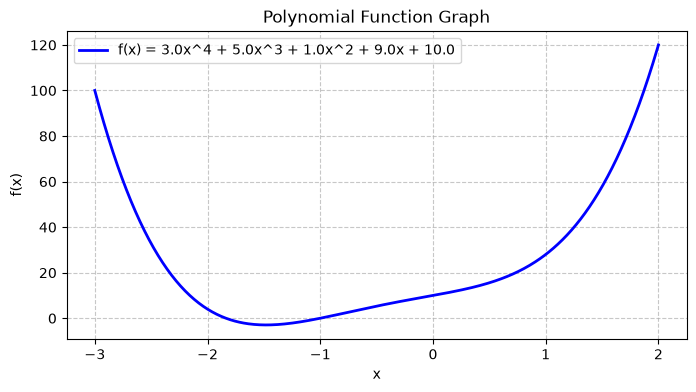

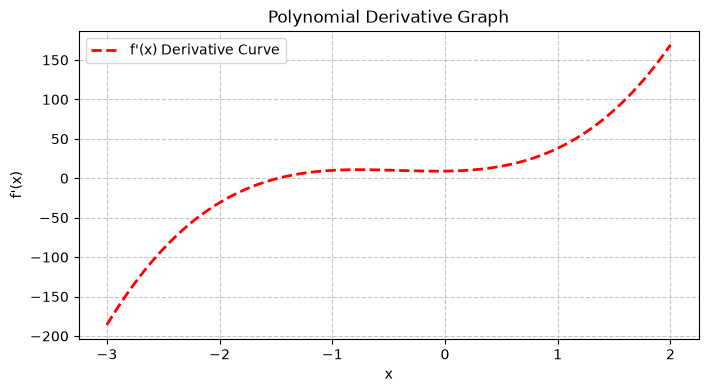

In [4]:
import numpy as np
import matplotlib.pyplot as plt

class Polynomial:
    def __init__(self, degree, coefficients):
        """Initialise a Polynomial with a degree and a list of coefficients.
        
        coefficients: list ordered from highest power to lowest power.
        Example: 3x^2 + 5x + 10 -> degree=2, coefficients=[3, 5, 10]
        """
        # Rule Check 1: Degree must be a non-negative integer (including 0-degree constants)
        if not isinstance(degree, int) or degree < 0:
            raise ValueError("Degree must be a non-negative integer.")
            
        # Rule Check 2: A polynomial of degree n must have exactly n + 1 coefficients
        if len(coefficients) != degree + 1:
            raise ValueError(f"A polynomial of degree {degree} must have exactly {degree + 1} coefficients.")
            
        self.degree = degree
        # Cast coefficients to float elements for numerical consistency
        self.coefficients = [float(c) for c in coefficients]

    def evaluate(self, x):
        """Evaluates the polynomial for a given value of the variable x."""
        result = 0.0
        # Iterate over coefficients mapping them to their respective power positions
        for i, coef in enumerate(self.coefficients):
            power = self.degree - i
            result += coef * (x ** power)
        return result

    def derivative(self, x):
        """Evaluates the first derivative of the polynomial for a given value of x."""
        result = 0.0
        for i, coef in enumerate(self.coefficients):
            power = self.degree - i
            if power > 0:
                # Power Rule: d/dx(c * x^n) = (c * n) * x^(n-1)
                result += (coef * power) * (x ** (power - 1))
        return result

    def plot(self, x_range):
        """Plots the polynomial over a specified range [x1, x2]."""
        if len(x_range) != 2 or x_range[0] >= x_range[1]:
            raise ValueError("x_range must be a list or tuple containing [x1, x2] where x1 < x2.")
            
        # Generate 500 linearly spaced mathematical evaluation sample steps
        x_vals = np.linspace(x_range[0], x_range[1], 500)
        y_vals = [self.evaluate(x) for x in x_vals]
        
        plt.figure(figsize=(8, 4))
        plt.plot(x_vals, y_vals, label=self._get_expression_string(), color="blue", linewidth=2)
        plt.title("Polynomial Function Graph")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()
        plt.show()

    def plot_derivative(self, x_range):
        """Plots the first derivative of the polynomial over a specified range [x1, x2]."""
        if len(x_range) != 2 or x_range[0] >= x_range[1]:
            raise ValueError("x_range must be a list or tuple containing [x1, x2] where x1 < x2.")
            
        x_vals = np.linspace(x_range[0], x_range[1], 500)
        y_vals = [self.derivative(x) for x in x_vals]
        
        plt.figure(figsize=(8, 4))
        plt.plot(x_vals, y_vals, label="f'(x) Derivative Curve", color="red", linestyle="--", linewidth=2)
        plt.title("Polynomial Derivative Graph")
        plt.xlabel("x")
        plt.ylabel("f'(x)")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()
        plt.show()

    def _get_expression_string(self):
        """Internal helper to construct a clean algebraic formula string representation."""
        terms = []
        for i, coef in enumerate(self.coefficients):
            power = self.degree - i
            if coef == 0:
                continue
            if power == 0:
                terms.append(f"{coef}")
            elif power == 1:
                terms.append(f"{coef}x")
            else:
                terms.append(f"{coef}x^{power}")
        return "f(x) = " + " + ".join(terms) if terms else "f(x) = 0"


# ==========================================
# SYSTEM TEST LOGIC
# ==========================================
if __name__ == "__main__":
    print("--- 1. Testing Validation Framework ---")
    try:
        # Invalid setup: Expected 5 coefficients for degree 4, but only 3 provided
        p_invalid = Polynomial(degree=4, coefficients=[3, 5, 1])
    except ValueError as e:
        print(f"Caught expected error perfectly: {e}")

    print("\n--- 2. Testing Example 1: 3x^4 + 5x^3 + x^2 + 9x + 10 ---")
    p1 = Polynomial(degree=4, coefficients=[3, 5, 1, 9, 10])
    
    # Evaluate at x = 2: 3(16) + 5(8) + 4 + 9(2) + 10 = 48 + 40 + 4 + 18 + 10 = 120
    print(f"Evaluation at x=2: {p1.evaluate(2)}") 
    
    # Derivative formula: 12x^3 + 15x^2 + 2x + 9
    # Evaluate derivative at x=2: 12(8) + 15(4) + 2(2) + 9 = 96 + 60 + 4 + 9 = 169
    print(f"Derivative evaluation at x=2: {p1.derivative(2)}")
    
    # Trigger UI visualization graphs inside the Colab output pane
    p1.plot([-3, 2])
    p1.plot_derivative([-3, 2])

## Problem-5

Design a system to model a simple online shopping cart. Create a class `Product` with attributes for `name` and `price`. Then, create a `ShoppingCart` class that has a list to store `Product` objects. Implement methods to `add_item(product)`, `remove_item(product_name)`, and `calculate_total()`.

In [5]:
class Product:
    def __init__(self, name, price):
        """Initialise a Product object with a descriptive name and floating point price."""
        self.name = name
        # Force float data structure formatting to ensure financial computation accuracy
        self.price = float(price)

    def __str__(self):
        """Clean string representation for displaying product item lines."""
        return f"{self.name} (${self.price:,.2f})"


class ShoppingCart:
    def __init__(self):
        """Initialise an empty ShoppingCart container with an item array list."""
        self.items = []  # Stores concrete Product object instances

    def add_item(self, product):
        """Adds a Product object instance into the active shopping cart collection."""
        self.items.append(product)
        print(f"Cart Success: Added {product.name} to your basket.")

    def remove_item(self, product_name):
        """Removes the first occurrence of a Product matching the provided product_name string."""
        # Loop through the list to look for a match on the property string attribute
        for product in self.items:
            # case=False style string matching protects against random case typing choices
            if product.name.strip().lower() == product_name.strip().lower():
                self.items.remove(product)
                print(f"Cart Success: Removed {product.name} from your basket.")
                return True
                
        print(f"Cart Warning: Could not find '{product_name}' in your active basket.")
        return False

    def calculate_total(self):
        """Accumulates and returns the final total price of all Product objects inside the basket."""
        # Use a generator expression to pull the price attribute out of every active item
        total = sum(product.price for product in self.items)
        return total

    def display_cart(self):
        """Prints a scannable summary breakdown of the current cart state."""
        print("\n--- Current Shopping Cart Receipt ---")
        if not self.items:
            print("[ Your shopping cart is empty ]")
        else:
            for item in self.items:
                print(f" • {item}")
        print(f"Total Amount Due: ${self.calculate_total():,.2f}\n" + "-"*35)


# ==========================================
# SYSTEM TEST LOGIC
# ==========================================
if __name__ == "__main__":
    print("--- 1. Initialising E-Commerce Store Catalog ---")
    
    # Instantiate standalone product entities
    prod1 = Product(name="Wireless Mouse", price=29.99)
    prod2 = Product(name="Mechanical Keyboard", price=89.50)
    prod3 = Product(name="USB-C Charging Cable", price=15.00)
    
    # Setup our cart container instance
    my_cart = ShoppingCart()
    my_cart.display_cart()

    print("\n--- 2. Executing Active Adding Scenarios ---")
    my_cart.add_item(prod1)
    my_cart.add_item(prod2)
    my_cart.add_item(prod3)
    # Add a duplicate mouse instance to verify duplicate tracking bounds work properly
    my_cart.add_item(prod1) 
    
    my_cart.display_cart()

    print("\n--- 3. Executing Removal and Financial Validation Scenarios ---")
    
    # Scenario A: Valid matching string remove
    my_cart.remove_item("Wireless Mouse") # Should drop exactly one mouse instance
    
    # Scenario B: Handle string safety spaces/casing
    my_cart.remove_item("  MECHANICAL KEYBOARD  ") 
    
    # Scenario C: Attempting to remove something that isn't inside the active list array
    my_cart.remove_item("Gaming Laptop")
    
    # Check out absolute final checkout states
    my_cart.display_cart()

--- 1. Initialising E-Commerce Store Catalog ---

--- Current Shopping Cart Receipt ---
[ Your shopping cart is empty ]
Total Amount Due: $0.00
-----------------------------------

--- 2. Executing Active Adding Scenarios ---
Cart Success: Added Wireless Mouse to your basket.
Cart Success: Added Mechanical Keyboard to your basket.
Cart Success: Added USB-C Charging Cable to your basket.
Cart Success: Added Wireless Mouse to your basket.

--- Current Shopping Cart Receipt ---
 • Wireless Mouse ($29.99)
 • Mechanical Keyboard ($89.50)
 • USB-C Charging Cable ($15.00)
 • Wireless Mouse ($29.99)
Total Amount Due: $164.48
-----------------------------------

--- 3. Executing Removal and Financial Validation Scenarios ---
Cart Success: Removed Wireless Mouse from your basket.
Cart Success: Removed Mechanical Keyboard from your basket.
Cart Warning: Could not find 'Gaming Laptop' in your active basket.

--- Current Shopping Cart Receipt ---
 • USB-C Charging Cable ($15.00)
 • Wireless Mouse (